# Pose Review — 48 Video Samples

Records 3 repetitions for each of 16 experimental sub-conditions (4 conditions × 4 sub-conditions = 48 videos total).  
Each video is 3 seconds, both agents performing **discussion** behaviour, recorded at a random animation offset.

### Design
| Cond | Name | What varies |
|------|------|-------------|
| 1 | Same 2D, Diff 3D pos | Agent positions differ in depth/angle while 2D projection is matched |
| 2 | Same 3D, Diff 2D pos | Camera angle changes (0° vs 60°) for same 3D agent positions |
| 3 | Same 2D, Diff 3D facing | Facing angle differs in 3D (flat vs tilted) |
| 4 | Same 3D, Diff 2D facing | Camera angle changes for same 3D facing configurations |

**Coordinate convention:** positions are `(lateral_m, depth_m)` relative to the baseline camera  
(`lateral > 0` = camera-right, `depth > 0` = forward). Facing angles use `atan2(depth, lateral)` convention  
(0° = camera-right, 90° = forward, 180° = camera-left).

**Prerequisites:** UE project on port 9000 · OBS Studio with WebSocket server enabled.

## 1. Imports & Connection

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'obsws-python'])

0

In [ ]:
import sys
import os
import math
import time
import random
import csv
import shutil
from pathlib import Path

import cv2
import numpy as np
import base64
from tqdm import tqdm
import obsws_python as obs

REPO_ROOT = Path().resolve().parent
sys.path.append(str(REPO_ROOT))
sys.path.append(str(Path().resolve()))  # for utils.py (same directory as this notebook)

from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV
from simworld.map.map import Map
from simworld.utils.vector import Vector
from simworld.config import Config

from utils import (
    spawn_humanoid,
    sample_sidewalk_positions,
    BP_METAHUMAN,
    BP_DISCUSSION1,
)

In [3]:
ucv          = UnrealCV()
communicator = Communicator(ucv)
config       = Config()

INFO:__init__:230:Got connection confirm: b'connected to SimWorld'


=>Info: using ip-port socket


## 2. Experimental Conditions

Each entry: `(cond_num, subplot_id, pos_a, angle_a, pos_b, angle_b, cam_offset)`
- `pos_*` = `(lateral_m, depth_m)` relative to baseline camera position
- `angle_*` = facing angle in degrees; `atan2(depth, lateral)` convention
- `cam_offset` = `(lateral_m, depth_m)` offset of camera from baseline

In [4]:
CONDITIONS = [
    # (cond, subplot_id, pos_a, angle_a_deg, pos_b, angle_b_deg, cam_offset)

    # Condition 1 — Same 2D, Diff 3D pos
    (1, 'near_in_plane',     (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, (0.00, 0.00)),
    (1, 'near_out_of_plane', (-1.00, 3.00),   0.0, ( 1.00,  5.00), 180.0, (0.00, 0.00)),
    (1, 'far_in_plane',      (-2.50, 4.00),   0.0, ( 2.50,  4.00), 180.0, (0.00, 0.00)),
    (1, 'far_out_of_plane',  (-2.50, 3.00),   0.0, ( 2.50,  5.00), 180.0, (0.00, 0.00)),

    # Condition 2 — Same 3D, Diff 2D pos
    # (2, 'near_cam0',         (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, ( 0.00, 0.00)),
    (2, 'near_cam60',        (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, ( 3.46, 2.00)),
    # (2, 'far_cam0',          (-3.00, 4.00),   0.0, ( 3.00,  4.00), 180.0, ( 0.00, 0.00)),
    (2, 'far_cam60',         (-2.50, 4.00),   0.0, ( 2.50,  4.00), 180.0, ( 3.46, 2.00)),

    # Condition 3 — Same 2D, Diff 3D facing
    # (3, 'facing_flat',       (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, (0.00, 0.00)),
    (3, 'facing_tilted',     (-1.00, 4.00),  60.0, ( 1.00,  4.00), 240.0, (0.00, 0.00)),
    (3, 'notfacing_flat',    (-1.00, 4.00), 180.0, ( 1.00,  4.00),   0.0, (0.00, 0.00)),
    (3, 'notfacing_tilted',  (-1.00, 4.00), 240.0, ( 1.00,  4.00),  60.0, (0.00, 0.00)),

    # Condition 4 — Same 3D, Diff 2D facing
    # (4, 'facing_cam0',       (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, ( 0.00, 0.00)),
    # (4, 'facing_cam60',      (-1.00, 4.00),   0.0, ( 1.00,  4.00), 180.0, ( 3.46, 2.00)),
    # (4, 'notfacing_cam0',    (-1.00, 4.00), 180.0, ( 1.00,  4.00),   0.0, ( 0.00, 0.00)),
    (4, 'notfacing_cam60',   (-1.00, 4.00), 180.0, ( 1.00,  4.00),   0.0, ( 3.46, 2.00)),
]

N_REPS  = 3
N_CONDS = len(CONDITIONS)
print(f'Conditions: {N_CONDS}  ×  Reps: {N_REPS}  =  {N_CONDS * N_REPS} videos')

Conditions: 10  ×  Reps: 3  =  30 videos


## 3. Configuration

In [ ]:
# -- OBS WebSocket -------------------------------------------------------------
OBS_HOST     = 'localhost'
OBS_PORT     = 4455
OBS_PASSWORD = os.environ['OBS_PASSWORD']  # OBS -> Tools -> WebSocket Server Settings
OBS_SOURCE_NAME = 'Window Capture'   # exact source name in OBS

# -- Timing (seconds) ---------------------------------------------------------
RECORD_DURATION_SEC = 3.0
SPAWN_WAIT_SEC      = 2.0
BEHAVIOR_BLEND_SEC  = 1.0
SETTLE_DELAY_SEC    = 0.3
OBS_FINALIZE_SEC    = 2.0

# -- Action sampling ----------------------------------------------------------
SAMPLE_MAX_SEC = 20.0   # sample start from first 20 s of each animation clip
MIN_ACTION_SEP =  2.0   # min gap between both agents' start offsets

# -- Character pool -----------------------------------------------------------
N_POOL             = 10
CHAR_SIM_THRESHOLD = 0.987
MAX_SPAWN_RETRIES  = 10

# -- Scene --------------------------------------------------------------------
SCENE_DIR           = '../data/example_city/demo_city_1'
ROADS_FILE          = os.path.join(SCENE_DIR, 'roads.json')
SIDEWALK_SEED       = 1
SIDEWALK_EDGE_INDEX = None

# -- Lighting -----------------------------------------------------------------
SUN_PITCH     = -75
SUN_YAW       = 45
SUN_INTENSITY = 200
FOG_DENSITY   = 1

# -- Camera defaults ----------------------------------------------------------
BASELINE_CAM_YAW   = 0      # original camera faces world +X
CAM_PITCH          = -5
CAM_ROLL           = 0
CAM_FOV            = 60
CAM_HEIGHT_CM      = 170
OBSERVER_CAM       = 0
CAM_RESOLUTION     = (1280, 720)

AGENT_Z_CM = 100

# -- Output directory ---------------------------------------------------------
OUTPUT_DIR = Path('output_pose_review')
OUTPUT_DIR.mkdir(exist_ok=True)
for item in OUTPUT_DIR.iterdir():
    if item.is_file() or item.is_symlink():
        item.unlink()
    else:
        shutil.rmtree(item)
print(f'Output dir: {OUTPUT_DIR.resolve()}')

## 4. Geometry & Recording Helpers

**Coordinate system** (fixed, based on baseline camera at yaw=0 facing world +X):
- `ORIG_FWD   = (1, 0)` — world +X = depth / camera forward
- `ORIG_RIGHT = (0, 1)` — world +Y = camera right

Table positions `(lat_m, dep_m)` → world (cm):  
`world = sidewalk_mid + dep * ORIG_FWD * 100 + lat * ORIG_RIGHT * 100`

Table facing angle θ → UE yaw:  
facing vector in table frame = `(cos θ, sin θ)` (lateral, depth);  
world vector = `sin(θ)*ORIG_FWD + cos(θ)*ORIG_RIGHT`;  
UE yaw = `atan2(wy, wx)`.

In [6]:
# Coordinate axes fixed to baseline camera (yaw = 0)
_yaw_rad   = math.radians(BASELINE_CAM_YAW)   # = 0
ORIG_FWD   = (math.cos(_yaw_rad),  math.sin(_yaw_rad))   # (1, 0)
ORIG_RIGHT = (math.sin(_yaw_rad),  math.cos(_yaw_rad))   # (0, 1)


def table_to_world(lat_m, dep_m, mid_x, mid_y):
    """Table (lateral_m, depth_m) → world (cm)."""
    wx = mid_x + dep_m * 100 * ORIG_FWD[0] + lat_m * 100 * ORIG_RIGHT[0]
    wy = mid_y + dep_m * 100 * ORIG_FWD[1] + lat_m * 100 * ORIG_RIGHT[1]
    return wx, wy


def table_angle_to_ue_yaw(theta_deg):
    """Table facing angle (atan2 convention) → UE world yaw (degrees)."""
    theta_rad = math.radians(theta_deg)
    lat = math.cos(theta_rad)   # lateral component of facing direction
    dep = math.sin(theta_rad)   # depth component
    wx_dir = dep * ORIG_FWD[0] + lat * ORIG_RIGHT[0]
    wy_dir = dep * ORIG_FWD[1] + lat * ORIG_RIGHT[1]
    return math.degrees(math.atan2(wy_dir, wx_dir))


def cam_yaw_toward(cam_wx, cam_wy, target_wx, target_wy):
    """UE yaw for camera to face a world-space target point."""
    return math.degrees(math.atan2(target_wy - cam_wy, target_wx - cam_wx))


def setup_camera_for_condition(cond_cfg, mid_x, mid_y):
    """Position and orient the camera for one condition.

    Returns (cam_wx, cam_wy, cam_yaw_deg).
    """
    cam_lat, cam_dep = cond_cfg  # table-frame offset
    cx, cy = table_to_world(cam_lat, cam_dep, mid_x, mid_y)

    if cam_lat == 0.0 and cam_dep == 0.0:
        cam_yaw = BASELINE_CAM_YAW
    else:
        # midpoint of agents in world space — computed later; pass as argument instead
        cam_yaw = None  # caller sets this after computing agent positions

    return cx, cy, cam_yaw


def record_video_obs(ws, out_path):
    """Record RECORD_DURATION_SEC via OBS WebSocket and save to out_path."""
    ws.start_record()
    time.sleep(RECORD_DURATION_SEC)
    resp = ws.stop_record()
    time.sleep(OBS_FINALIZE_SEC)

    recorded = getattr(resp, 'output_path', '')
    if recorded and os.path.exists(recorded):
        for attempt in range(5):
            try:
                os.replace(recorded, out_path)
                return True
            except PermissionError:
                if attempt < 4:
                    time.sleep(1.0)
                else:
                    tqdm.write(f'  [warn] could not move {recorded!r}')
                    return False
    else:
        tqdm.write(f'  [warn] OBS outputPath not found: {recorded!r}')
        return False


print('Helpers defined.')

Helpers defined.


## 5. Scene & Baseline Camera Setup

In [7]:
city_map = Map(config)
city_map.initialize_map_from_file(roads_file=ROADS_FILE)

_pa, _pb, chosen_edge = sample_sidewalk_positions(
    city_map, agent_spacing_cm=100, min_edge_length_cm=3000,
    edge_index=SIDEWALK_EDGE_INDEX, seed=SIDEWALK_SEED,
)
SIDEWALK_MID_X = (_pa.x + _pb.x) / 2
SIDEWALK_MID_Y = (_pa.y + _pb.y) / 2
print(f'Sidewalk mid: ({SIDEWALK_MID_X:.0f}, {SIDEWALK_MID_Y:.0f}) cm')

Sidewalk mid: (50000, -1700) cm


In [8]:
weather_name = config['simworld.ue_manager_path'].split('.')[0].split('/')[-1]
communicator.set_sun_direction(weather_name, pitch=SUN_PITCH, yaw=SUN_YAW)
communicator.set_sun_intensity(weather_name, intensity=SUN_INTENSITY)
communicator.set_fog(weather_name, density=FOG_DENSITY, distance=3000, falloff=0.5)
print(f'Lighting set: sun pitch={SUN_PITCH}° yaw={SUN_YAW}° intensity={SUN_INTENSITY} fog={FOG_DENSITY}')

Lighting set: sun pitch=-75° yaw=45° intensity=200 fog=1


In [9]:
# Set baseline camera (will be overridden per-condition during recording)
BASELINE_CAM_X = SIDEWALK_MID_X
BASELINE_CAM_Y = SIDEWALK_MID_Y
BASELINE_CAM_Z = CAM_HEIGHT_CM

ucv.set_camera_location(OBSERVER_CAM, (BASELINE_CAM_X, BASELINE_CAM_Y, BASELINE_CAM_Z))
ucv.set_camera_rotation(OBSERVER_CAM, (CAM_PITCH, BASELINE_CAM_YAW, CAM_ROLL))
ucv.set_camera_fov(OBSERVER_CAM, CAM_FOV)
ucv.set_camera_resolution(OBSERVER_CAM, CAM_RESOLUTION)
ucv.client.request(f'vset /camera/{OBSERVER_CAM}/reflection Lumen')
ucv.client.request(f'vset /camera/{OBSERVER_CAM}/illumination Lumen')

# Holding position for parked agents (far behind the baseline camera)
HOLDING_X  = BASELINE_CAM_X - 5000
HOLDING_Y0 = BASELINE_CAM_Y - (N_POOL // 2) * 300
HOLDING_STEP = 300

print(f'Baseline camera: ({BASELINE_CAM_X:.0f}, {BASELINE_CAM_Y:.0f}, {BASELINE_CAM_Z}) cm, yaw={BASELINE_CAM_YAW}°')

Baseline camera: (50000, -1700, 170) cm, yaw=0°


## 6. Connect to OBS

In [10]:
ws = obs.ReqClient(host=OBS_HOST, port=OBS_PORT, password=OBS_PASSWORD)
print('OBS connected.')

OBS connected.


## 7. Build Character Pool (10 Unique Characters)

Spawns agents one at a time, captures a screenshot, and accepts only visually distinct characters.  
Accepted agents are parked behind the camera and reused throughout the batch.

In [11]:
def capture_ref_image_obs(ws, source_name, width=1280, height=720):
    resp = ws.get_source_screenshot(source_name, 'png', width, height, -1)
    b64  = resp.image_data.split(',', 1)[1]
    arr  = np.frombuffer(base64.b64decode(b64), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)


def _pixel_sim(a, b):
    a = a.astype(np.float32); b = b.astype(np.float32)
    if a.shape != b.shape:
        b = cv2.resize(b, (a.shape[1], a.shape[0]))
    return float(1.0 - np.mean(np.abs(a - b)) / 255.0)


def is_duplicate(img, accepted, threshold):
    for ref in accepted:
        sim = _pixel_sim(img, ref)
        print(f'    pixel_sim={sim:.4f}  threshold={threshold}')
        if sim >= threshold:
            return True
    return False


print('Pool helpers defined.')

Pool helpers defined.


(50200.0, -1700.0, 100)
  [01/10] Accepted  name=GEN_BP_Humanoid_0  (attempt 1)
(50200.0, -1700.0, 100)
    pixel_sim=0.9639  threshold=0.987
  [02/10] Accepted  name=GEN_BP_Humanoid_1  (attempt 2)
(50200.0, -1700.0, 100)
    pixel_sim=0.9656  threshold=0.987
    pixel_sim=0.9773  threshold=0.987
  [03/10] Accepted  name=GEN_BP_Humanoid_2  (attempt 3)
(50200.0, -1700.0, 100)
    pixel_sim=0.9697  threshold=0.987
    pixel_sim=0.9792  threshold=0.987
    pixel_sim=0.9797  threshold=0.987
  [04/10] Accepted  name=GEN_BP_Humanoid_3  (attempt 4)
(50200.0, -1700.0, 100)
    pixel_sim=0.9681  threshold=0.987
    pixel_sim=0.9779  threshold=0.987
    pixel_sim=0.9854  threshold=0.987
    pixel_sim=0.9811  threshold=0.987
  [05/10] Accepted  name=GEN_BP_Humanoid_4  (attempt 5)
(50200.0, -1700.0, 100)
    pixel_sim=0.9722  threshold=0.987
    pixel_sim=0.9679  threshold=0.987
    pixel_sim=0.9759  threshold=0.987
    pixel_sim=0.9772  threshold=0.987
    pixel_sim=0.9739  threshold=0.987
  [06/

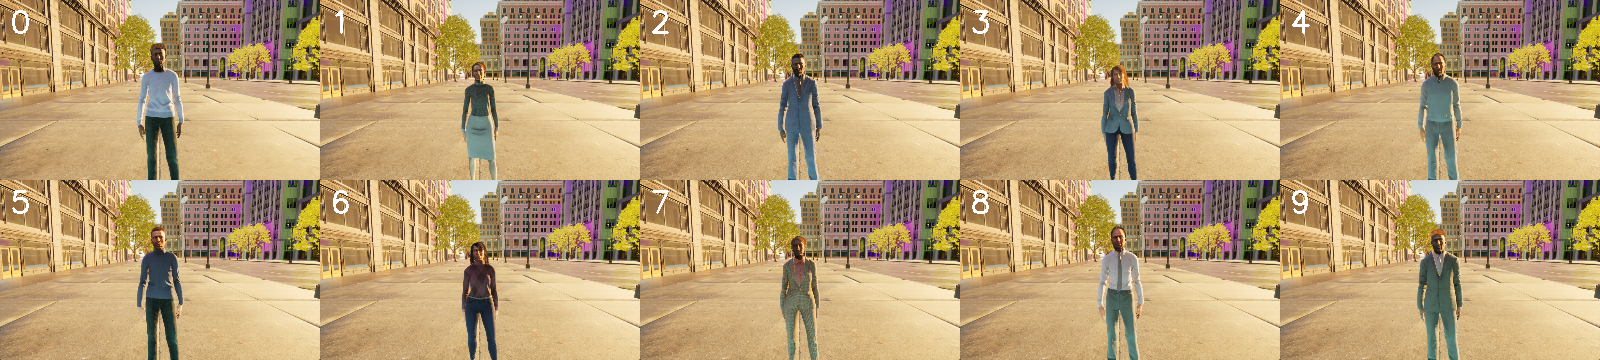

Pool ready: 10/10 | 10 total spawns
Contact sheet: output_pose_review\character_pool_sheet.png


In [12]:
# Reference pose: agent 2 m in front of baseline camera, facing back toward it
_ref_depth_m = 2.0
REF_POS_X = BASELINE_CAM_X + _ref_depth_m * 100 * ORIG_FWD[0]
REF_POS_Y = BASELINE_CAM_Y + _ref_depth_m * 100 * ORIG_FWD[1]
REF_DIR_X = -ORIG_FWD[0]
REF_DIR_Y = -ORIG_FWD[1]

pool_images = []   # BGR screenshots of accepted characters
agent_pool  = []   # (agent_obj, ue_name, park_x, park_y)

_attempt = 0
_max     = MAX_SPAWN_RETRIES * N_POOL

print(f'Collecting {N_POOL} unique characters (threshold={CHAR_SIM_THRESHOLD}) ...')

while len(agent_pool) < N_POOL and _attempt < _max:
    _attempt += 1
    _slot = len(agent_pool)

    _a = spawn_humanoid(
        communicator, config,
        position=Vector(REF_POS_X, REF_POS_Y),
        direction=Vector(REF_DIR_X, REF_DIR_Y),
        name=f'Pool_{_slot:02d}',
        blueprint_path=BP_DISCUSSION1,
    )
    time.sleep(SPAWN_WAIT_SEC)
    _n = communicator.get_humanoid_name(_a.id)

    _img = capture_ref_image_obs(ws, OBS_SOURCE_NAME)

    if is_duplicate(_img, pool_images, CHAR_SIM_THRESHOLD):
        print(f'  [attempt {_attempt:03d}] Duplicate → destroying, retrying ...')
        ucv.destroy(_n)
        time.sleep(0.2)
        continue

    _park_x = HOLDING_X
    _park_y = HOLDING_Y0 + _slot * HOLDING_STEP
    ucv.set_location([_park_x, _park_y, AGENT_Z_CM], _n)
    pool_images.append(_img)
    agent_pool.append((_a, _n, _park_x, _park_y))
    time.sleep(0.3)
    print(f'  [{len(agent_pool):02d}/{N_POOL}] Accepted  name={_n}  (attempt {_attempt})')

# Contact sheet
_tw, _th = 320, 180
_cols    = 5
_rows    = math.ceil(len(pool_images) / _cols)
_sheet   = np.zeros((_rows * _th, _cols * _tw, 3), dtype=np.uint8)
for _i, _img in enumerate(pool_images):
    _thumb = cv2.resize(_img, (_tw, _th))
    cv2.putText(_thumb, str(_i), (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
    _r, _c = divmod(_i, _cols)
    _sheet[_r * _th:(_r + 1) * _th, _c * _tw:(_c + 1) * _tw] = _thumb

_sheet_path = OUTPUT_DIR / 'character_pool_sheet.png'
cv2.imwrite(str(_sheet_path), _sheet)
communicator.show_img(_sheet)
print(f'Pool ready: {len(agent_pool)}/{N_POOL} | {_attempt} total spawns')
print(f'Contact sheet: {_sheet_path}')

## 8. Generate 48 Videos

Outer loop: 16 conditions.  
Inner loop: 3 repetitions — same geometry/camera, different randomly drawn agent pair.

Filename: `c{cond}_{subplot}_r{rep}.mp4`  
Resume-safe: existing files are skipped.

In [13]:
total   = N_CONDS * N_REPS
saved   = 0
skipped = 0
errors  = 0

METADATA_FILE = OUTPUT_DIR / 'metadata.csv'
_write_header = not METADATA_FILE.exists()
_meta_f = open(METADATA_FILE, 'a', newline='', encoding='utf-8')
_meta_w = csv.DictWriter(_meta_f, fieldnames=[
    'video_file', 'condition', 'subplot',
    'pos_a_lat_m', 'pos_a_dep_m', 'angle_a_deg',
    'pos_b_lat_m', 'pos_b_dep_m', 'angle_b_deg',
    'cam_offset_lat_m', 'cam_offset_dep_m',
    'rep', 'agent_a_pool_idx', 'agent_b_pool_idx',
    'action_start_a_s', 'action_start_b_s',
])
if _write_header:
    _meta_w.writeheader()

pbar = tqdm(total=total, desc='Recording')

try:
    for cond_num, subplot, pos_a, angle_a, pos_b, angle_b, cam_offset in CONDITIONS:
        for rep in range(1, N_REPS + 1):

            out_path = OUTPUT_DIR / f'c{cond_num}_{subplot}_r{rep}.mp4'
            if out_path.exists():
                skipped += 1
                pbar.update(1)
                continue

            # ---- Agent positions and orientations ---------------------------
            ax, ay = table_to_world(pos_a[0], pos_a[1], SIDEWALK_MID_X, SIDEWALK_MID_Y)
            bx, by = table_to_world(pos_b[0], pos_b[1], SIDEWALK_MID_X, SIDEWALK_MID_Y)
            yaw_a  = table_angle_to_ue_yaw(angle_a)
            yaw_b  = table_angle_to_ue_yaw(angle_b)

            # ---- Camera position and orientation ----------------------------
            cx, cy = table_to_world(cam_offset[0], cam_offset[1],
                                    SIDEWALK_MID_X, SIDEWALK_MID_Y)
            if cam_offset == (0.0, 0.0):
                cam_yaw = BASELINE_CAM_YAW
            else:
                mid_wx = (ax + bx) / 2
                mid_wy = (ay + by) / 2
                cam_yaw = cam_yaw_toward(cx, cy, mid_wx, mid_wy)

            ucv.set_camera_location(OBSERVER_CAM, (cx, cy, CAM_HEIGHT_CM))
            ucv.set_camera_rotation(OBSERVER_CAM, (CAM_PITCH, cam_yaw, CAM_ROLL))

            # ---- Pick two distinct agents -----------------------------------
            idx_a, idx_b = random.sample(range(len(agent_pool)), 2)
            _, NAME_A, park_ax, park_ay = agent_pool[idx_a]
            _, NAME_B, park_bx, park_by = agent_pool[idx_b]

            # ---- Place agents -----------------------------------------------
            ucv.set_location([ax, ay, AGENT_Z_CM], NAME_A)
            ucv.set_orientation([0, yaw_a, 0],     NAME_A)
            ucv.set_location([bx, by, AGENT_Z_CM], NAME_B)
            ucv.set_orientation([0, yaw_b, 0],     NAME_B)
            time.sleep(SETTLE_DELAY_SEC)

            # ---- Staggered animation start (random offset within clip) ------
            var_a    = 0
            var_b    = 0
            offset_a = random.randint(0, int(SAMPLE_MAX_SEC))
            offset_b = random.randint(0, int(SAMPLE_MAX_SEC))
            if var_a == var_b:
                while abs(offset_a - offset_b) < MIN_ACTION_SEP:
                    offset_b = random.randint(0, int(SAMPLE_MAX_SEC))

            if offset_a >= offset_b:
                ucv.humanoid_discuss(NAME_A, discuss_type=var_a)
                time.sleep(offset_a - offset_b)
                ucv.humanoid_discuss(NAME_B, discuss_type=var_b)
                time.sleep(offset_b)
            else:
                ucv.humanoid_discuss(NAME_B, discuss_type=var_b)
                time.sleep(offset_b - offset_a)
                ucv.humanoid_discuss(NAME_A, discuss_type=var_a)
                time.sleep(offset_a)
            time.sleep(BEHAVIOR_BLEND_SEC)

            tqdm.write(
                f'  {out_path.name}  '
                f'agents:{NAME_A}(idx={idx_a})/{NAME_B}(idx={idx_b})  '
                f'var:{var_a}/{var_b}  offsets:{offset_a}s/{offset_b}s  '
                f'cam_yaw:{cam_yaw:.1f}°'
            )

            # ---- Record -----------------------------------------------------
            ok = record_video_obs(ws, out_path)
            if ok:
                saved += 1
                _meta_w.writerow({
                    'video_file':         out_path.name,
                    'condition':          cond_num,
                    'subplot':            subplot,
                    'pos_a_lat_m':        pos_a[0],
                    'pos_a_dep_m':        pos_a[1],
                    'angle_a_deg':        angle_a,
                    'pos_b_lat_m':        pos_b[0],
                    'pos_b_dep_m':        pos_b[1],
                    'angle_b_deg':        angle_b,
                    'cam_offset_lat_m':   cam_offset[0],
                    'cam_offset_dep_m':   cam_offset[1],
                    'rep':                rep,
                    'agent_a_pool_idx':   idx_a,
                    'agent_b_pool_idx':   idx_b,
                    'action_start_a_s':   offset_a,
                    'action_start_b_s':   offset_b,
                })
                _meta_f.flush()
            else:
                errors += 1
            pbar.update(1)

            # ---- Stop actions, return agents to parking ----------------------
            ucv.humanoid_stop_current_action(NAME_A)
            ucv.humanoid_stop_current_action(NAME_B)
            ucv.set_location([park_ax, park_ay, AGENT_Z_CM], NAME_A)
            ucv.set_location([park_bx, park_by, AGENT_Z_CM], NAME_B)
            time.sleep(0.2)

finally:
    _meta_f.close()

# Reset camera to baseline after batch
ucv.set_camera_location(OBSERVER_CAM, (BASELINE_CAM_X, BASELINE_CAM_Y, BASELINE_CAM_Z))
ucv.set_camera_rotation(OBSERVER_CAM, (CAM_PITCH, BASELINE_CAM_YAW, CAM_ROLL))

pbar.close()
print(f'Done. saved={saved}  skipped={skipped}  errors={errors}  total={saved+skipped+errors}')
print(f'Output  : {OUTPUT_DIR.resolve()}')
print(f'Metadata: {METADATA_FILE.resolve()}')

Recording:   0%|          | 0/30 [00:00<?, ?it/s]

Recording:   0%|          | 0/30 [00:08<?, ?it/s]

  c1_near_in_plane_r1.mp4  agents:GEN_BP_Humanoid_6(idx=6)/GEN_BP_Humanoid_5(idx=5)  var:0/0  offsets:5s/7s  cam_yaw:0.0°


Recording:   3%|▎         | 1/30 [00:28<06:31, 13.51s/it]

  c1_near_in_plane_r2.mp4  agents:GEN_BP_Humanoid_7(idx=7)/GEN_BP_Humanoid_2(idx=2)  var:0/0  offsets:13s/7s  cam_yaw:0.0°


...

  c4_notfacing_cam60_r2.mp4  agents:GEN_BP_Humanoid_2(idx=2)/GEN_BP_Humanoid_9(idx=9)  var:0/0  offsets:13s/4s  cam_yaw:-60.0°


Recording:  97%|█████████▋| 29/30 [10:26<00:20, 20.95s/it]

  c4_notfacing_cam60_r3.mp4  agents:GEN_BP_Humanoid_8(idx=8)/GEN_BP_Humanoid_3(idx=3)  var:0/0  offsets:17s/7s  cam_yaw:-60.0°


Recording: 100%|██████████| 30/30 [10:31<00:00, 21.06s/it]

Done. saved=30  skipped=0  errors=0  total=30
Output  : C:\Users\Shadow\OneDrive - Johns Hopkins\SimWorld\pose_review\output_pose_review
Metadata: C:\Users\Shadow\OneDrive - Johns Hopkins\SimWorld\pose_review\output_pose_review\metadata.csv


## 8b. Regenerate a Specific Video

After manual review, use this cell to re-record any single video.  
Set `REGEN_TARGET` to the filename (e.g. `'c1_near_in_plane_r2.mp4'`) and run the cell.  
The existing file and its metadata row will be overwritten.

In [14]:
# ── Set this to the filename you want to re-record ───────────────────────────
REGEN_TARGET = 'c1_near_in_plane_r2.mp4'
# ─────────────────────────────────────────────────────────────────────────────

import re

def _parse_video_name(name):
    """Return (cond_num, subplot, rep) from a filename like c1_near_in_plane_r2.mp4."""
    m = re.fullmatch(r'c(\d+)_(.+)_r(\d+)\.mp4', Path(name).name)
    if not m:
        raise ValueError(f'Cannot parse video name: {name!r}')
    return int(m.group(1)), m.group(2), int(m.group(3))

def _find_condition(cond_num, subplot):
    for entry in CONDITIONS:
        if entry[0] == cond_num and entry[1] == subplot:
            return entry
    raise ValueError(f'Condition not found: cond={cond_num} subplot={subplot!r}')

def _rewrite_metadata_row(meta_path, new_row):
    """Replace the row whose video_file matches new_row['video_file'], or append."""
    if not meta_path.exists():
        return
    with open(meta_path, 'r', newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    fieldnames = list(rows[0].keys()) if rows else list(new_row.keys())
    updated = False
    for i, r in enumerate(rows):
        if r['video_file'] == new_row['video_file']:
            rows[i] = new_row
            updated = True
            break
    if not updated:
        rows.append(new_row)
    with open(meta_path, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)

def regenerate_video(target_name):
    cond_num, subplot, rep = _parse_video_name(target_name)
    cond_cfg = _find_condition(cond_num, subplot)
    _, _, pos_a, angle_a, pos_b, angle_b, cam_offset = cond_cfg

    out_path = OUTPUT_DIR / target_name
    print(f'Regenerating: {out_path.name}  (cond={cond_num} subplot={subplot!r} rep={rep})')

    # Agent world positions and orientations
    ax, ay = table_to_world(pos_a[0], pos_a[1], SIDEWALK_MID_X, SIDEWALK_MID_Y)
    bx, by = table_to_world(pos_b[0], pos_b[1], SIDEWALK_MID_X, SIDEWALK_MID_Y)
    yaw_a  = table_angle_to_ue_yaw(angle_a)
    yaw_b  = table_angle_to_ue_yaw(angle_b)

    # Camera
    cx, cy = table_to_world(cam_offset[0], cam_offset[1], SIDEWALK_MID_X, SIDEWALK_MID_Y)
    if cam_offset == (0.0, 0.0):
        cam_yaw = BASELINE_CAM_YAW
    else:
        mid_wx = (ax + bx) / 2
        mid_wy = (ay + by) / 2
        cam_yaw = cam_yaw_toward(cx, cy, mid_wx, mid_wy)

    ucv.set_camera_location(OBSERVER_CAM, (cx, cy, CAM_HEIGHT_CM))
    ucv.set_camera_rotation(OBSERVER_CAM, (CAM_PITCH, cam_yaw, CAM_ROLL))

    # Pick two distinct agents
    idx_a, idx_b = random.sample(range(len(agent_pool)), 2)
    _, NAME_A, park_ax, park_ay = agent_pool[idx_a]
    _, NAME_B, park_bx, park_by = agent_pool[idx_b]

    # Place agents
    ucv.set_location([ax, ay, AGENT_Z_CM], NAME_A)
    ucv.set_orientation([0, yaw_a, 0],     NAME_A)
    ucv.set_location([bx, by, AGENT_Z_CM], NAME_B)
    ucv.set_orientation([0, yaw_b, 0],     NAME_B)
    time.sleep(SETTLE_DELAY_SEC)

    # Staggered animation offsets
    var_a    = 1
    var_b    = 1
    offset_a = random.randint(0, int(SAMPLE_MAX_SEC))
    offset_b = random.randint(0, int(SAMPLE_MAX_SEC))
    if var_a == var_b:
        while abs(offset_a - offset_b) < MIN_ACTION_SEP:
            offset_b = random.randint(0, int(SAMPLE_MAX_SEC))

    if offset_a >= offset_b:
        ucv.humanoid_discuss(NAME_A, discuss_type=var_a)
        time.sleep(offset_a - offset_b)
        ucv.humanoid_discuss(NAME_B, discuss_type=var_b)
        time.sleep(offset_b)
    else:
        ucv.humanoid_discuss(NAME_B, discuss_type=var_b)
        time.sleep(offset_b - offset_a)
        ucv.humanoid_discuss(NAME_A, discuss_type=var_a)
        time.sleep(offset_a)
    time.sleep(BEHAVIOR_BLEND_SEC)

    print(
        f'  agents:{NAME_A}(idx={idx_a})/{NAME_B}(idx={idx_b})  '
        f'var:{var_a}/{var_b}  offsets:{offset_a}s/{offset_b}s  '
        f'cam_yaw:{cam_yaw:.1f}°'
    )

    # Delete old file so OBS can overwrite cleanly
    if out_path.exists():
        out_path.unlink()

    ok = record_video_obs(ws, out_path)

    # Stop actions and return agents to parking
    ucv.humanoid_stop_current_action(NAME_A)
    ucv.humanoid_stop_current_action(NAME_B)
    ucv.set_location([park_ax, park_ay, AGENT_Z_CM], NAME_A)
    ucv.set_location([park_bx, park_by, AGENT_Z_CM], NAME_B)

    # Reset camera to baseline
    ucv.set_camera_location(OBSERVER_CAM, (BASELINE_CAM_X, BASELINE_CAM_Y, BASELINE_CAM_Z))
    ucv.set_camera_rotation(OBSERVER_CAM, (CAM_PITCH, BASELINE_CAM_YAW, CAM_ROLL))

    if ok:
        _rewrite_metadata_row(METADATA_FILE, {
            'video_file':         out_path.name,
            'condition':          cond_num,
            'subplot':            subplot,
            'pos_a_lat_m':        pos_a[0],
            'pos_a_dep_m':        pos_a[1],
            'angle_a_deg':        angle_a,
            'pos_b_lat_m':        pos_b[0],
            'pos_b_dep_m':        pos_b[1],
            'angle_b_deg':        angle_b,
            'cam_offset_lat_m':   cam_offset[0],
            'cam_offset_dep_m':   cam_offset[1],
            'rep':                rep,
            'agent_a_pool_idx':   idx_a,
            'agent_b_pool_idx':   idx_b,
            'action_start_a_s':   offset_a,
            'action_start_b_s':   offset_b,
        })
        print(f'  Saved: {out_path}')
    else:
        print(f'  [error] Recording failed for {out_path.name}')

regenerate_video(REGEN_TARGET)

Regenerating: c1_near_in_plane_r2.mp4  (cond=1 subplot='near_in_plane' rep=2)
  agents:GEN_BP_Humanoid_5(idx=5)/GEN_BP_Humanoid_4(idx=4)  var:1/1  offsets:0s/7s  cam_yaw:0.0°
  Saved: output_pose_review\c1_near_in_plane_r2.mp4


## 9. Quick Verification

MP4 files in output dir: 30 / 30
Preview: c3_notfacing_tilted_r2.mp4


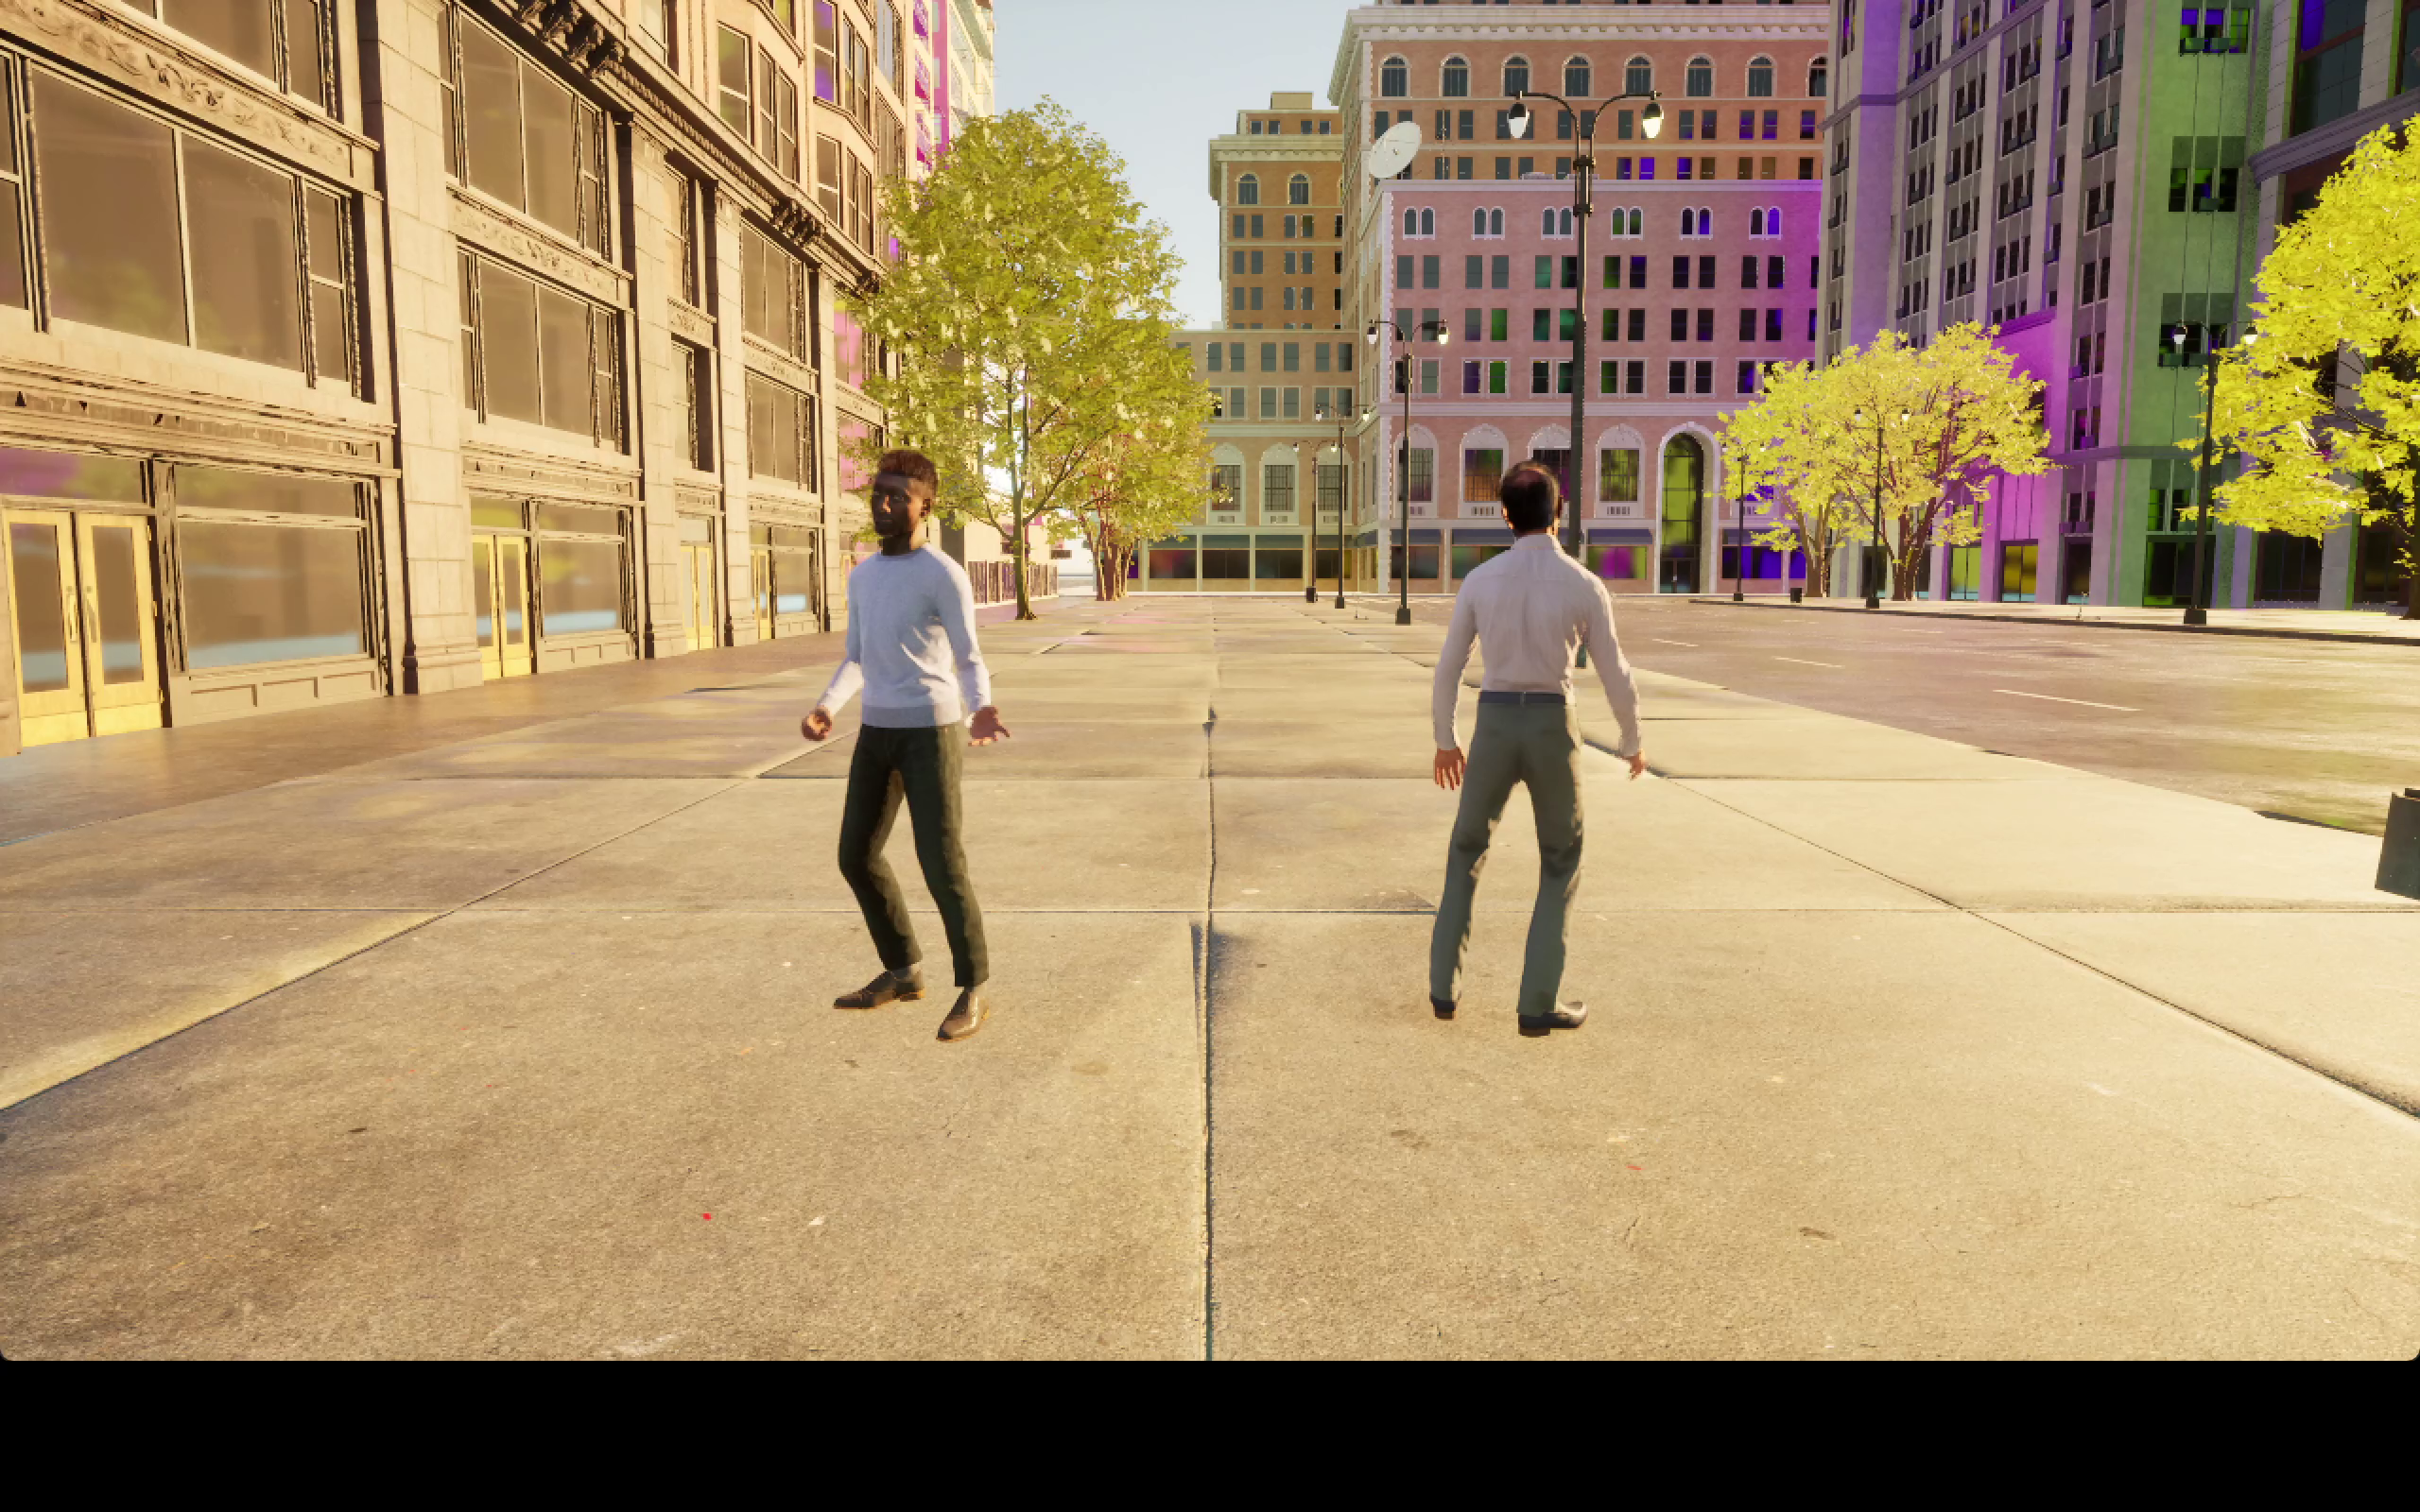

In [15]:
saved_files = sorted(OUTPUT_DIR.glob('c*.mp4'))
print(f'MP4 files in output dir: {len(saved_files)} / {N_CONDS * N_REPS}')

if saved_files:
    sample_path = random.choice(saved_files)
    print(f'Preview: {sample_path.name}')
    cap = cv2.VideoCapture(str(sample_path))
    ret, frame = cap.read()
    cap.release()
    if ret:
        communicator.show_img(frame)

## 10. Cleanup

In [16]:
ws.disconnect()
communicator.disconnect()
print('Cleaned up.')

Cleaned up.
